## Import necessary labraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Read the online payment fraud detection csv file using pandas commands.

In [3]:
df=pd.read_csv("onlinepayment_fraud_Detection.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0,0


### Finding some basic information about the dataset

In [4]:
df  #showing the dataset attributes 

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0,0


In [5]:
df.columns # columns present in dataset

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.dtypes #datatypes of the columns

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [7]:
df.shape # Returns the number of rows and columns in the DataFrame

(1048575, 11)

**Observation:** 
The data is containing 1048575 rows and 11 columns

### Explore data

 #### .head() will return you the initial rows of the dataset.

In [8]:
df.head()   #to preview the first few rows

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
#info is a function that returns the basic iformation like number of non-null values, dtype and all the columns.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


**Observation:**
1. All the columns have 1048575 datapoints.
2. The columns belongs to object, float, and int data types.

In [10]:
df.describe()  # Provides a statistical summary of numerical columns (count, mean, std, min, max, quartiles)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [11]:
df.isnull().sum()   # Shows the total number of missing (null) values in each column

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

**observation:**
- We have fixed columns names,data types,and other
- There is no duplicates or null value found.

### Understand Categories

In [12]:
df.columns[df.isnull().any()] # Returns the names of columns that contain at least one missing value


Index([], dtype='object')

In [13]:
df['type'].value_counts()  # Displays the count of unique values in a column

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

### 1 Handle Missing Data


In [14]:
df.dropna(inplace=True)  # remove rows with missing values


In [15]:
df.shape

(1048575, 11)

### 2 Remove Duplicates


In [16]:
# Checks for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

***Observation:***
There are no duplicate rows in the dataset, so all records are unique.

### 3 Fix Inconsistencies in Categorical Data


In [17]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [18]:
cat_cols = df.select_dtypes(include='object').columns  # Selects and stores all categorical (object-type) column names from the DataFrame

In [19]:
cat_cols

Index(['type', 'nameOrig', 'nameDest'], dtype='object')

In [20]:
# Convert categorical column values to lowercase for consistency
df['type'] = df['type'].str.lower()


In [21]:
df['type'].head()


0     payment
1     payment
2    transfer
3    cash_out
4     payment
Name: type, dtype: object

In [22]:
 # Remove leading and trailing whitespace
df['nameOrig'] = df['nameOrig'].str.strip()


### 4 Convert Data Types


In [23]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [24]:
# List of columns to convert
cat_cols = ['type', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
# Convert to category type
df[cat_cols] = df[cat_cols].astype('category')


In [25]:
# Check dtypes after conversion
df.dtypes

step                 int64
type              category
amount             float64
nameOrig          category
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest          category
oldbalanceDest     float64
newbalanceDest     float64
isFraud           category
isFlaggedFraud    category
dtype: object

### 5 Non-Visual Bivariate Analysis


***Categorical vs Categorical: Compare group-wise counts***

In [26]:
# Using value_counts
df['type'].value_counts()

type
cash_out    373641
payment     353873
cash_in     227130
transfer     86753
debit         7178
Name: count, dtype: int64

In [27]:
# Compare with another categorical column (cross-tab)
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
cash_in,227130,0
cash_out,373063,578
debit,7178,0
payment,353873,0
transfer,86189,564


**Observation**
- CASH_OUT and TRANSFER transactions have most of the fraud cases.
- Other transaction types (CASH_IN, PAYMENT, DEBIT) have no fraud cases.


***Categorical vs Numerical: Analyze averages or medians for each group***

In [28]:
# Mean per category
df.groupby('type')['amount'].mean()


type
cash_in     169923.648522
cash_out    184039.592505
debit         5878.516989
payment      11122.907151
transfer    634403.832422
Name: amount, dtype: float64

**Observations:**
- TRANSFER transactions have the highest average amount.
- DEBIT and PAYMENT transactions have the lowest average amounts.
- CASH_OUT and CASH_IN have moderate average amounts.

In [29]:
# Median per category
df.groupby('type')['amount'].median()

type
cash_in     143609.760
cash_out    154200.130
debit         3247.175
payment       8597.620
transfer    460761.850
Name: amount, dtype: float64

**Observations:**
- TRANSFER transactions have the highest median amount.
- DEBIT and PAYMENT transactions have the lowest median amounts.
- CASH_OUT and CASH_IN have moderate median amounts.

***Numerical vs Numerical: Explore correlation or differences in trends*** 

In [30]:
# Correlation
df['amount'].corr(df['newbalanceOrig'])

np.float64(-0.001133058265545849)

In [31]:
num_cols=['step','amount','oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','isFraud']
corr_matrix=df[num_cols].corr()
corr_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
step,1.000000,-0.025996,-0.006780,-0.007180,-0.002251,-0.019503,0.045030
amount,-0.025996,1.000000,0.004864,-0.001133,0.215558,0.311936,0.128862
oldbalanceOrg,-0.006780,0.004864,1.000000,0.999047,0.093305,0.064049,0.003829
newbalanceOrig,-0.007180,-0.001133,0.999047,1.000000,0.095182,0.063725,-0.009438
oldbalanceDest,-0.002251,0.215558,0.093305,0.095182,1.000000,0.978403,-0.007552
newbalanceDest,-0.019503,0.311936,0.064049,0.063725,0.978403,1.000000,-0.000495
isFraud,0.045030,0.128862,0.003829,-0.009438,-0.007552,-0.000495,1.000000


**Observations:**
- Origin and destination balances (oldbalanceOrg & newbalanceOrig, oldbalanceDest & newbalanceDest) are highly correlated.
- Transaction amount has a small positive correlation with fraud (isFraud), while other features show little correlation.

### Visualization

***Univariate Analysis***

In [32]:
# Boxplots display the spread and outliers of numerical columns in the dataset

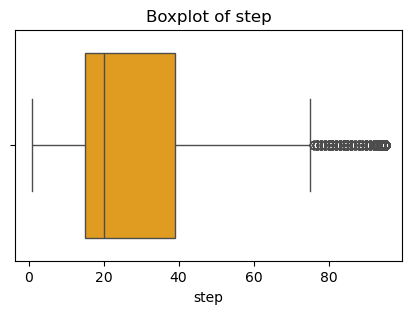

In [33]:
# Boxplot for 'amount'
plt.figure(figsize=(5,3))
sns.boxplot(x=df['step'], color='orange')
plt.title('Boxplot of step')
plt.show()

**Observation**
- step values are widely spread, meaning transactions occur across many time periods.
- The distribution is not tightly clustered, showing activity over a long duration.
- Outliers may be present, indicating very early or very late time steps.
- No negative values → data is valid and consistent.

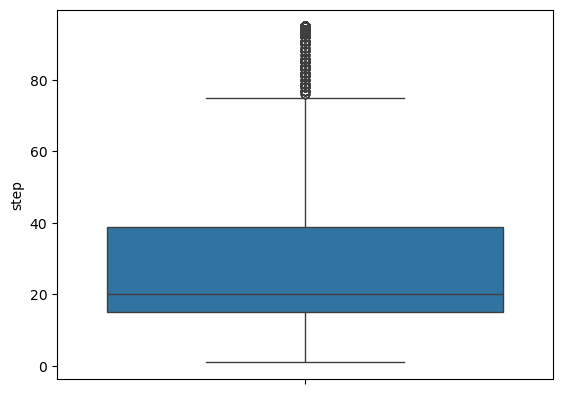

<Figure size 300x200 with 0 Axes>

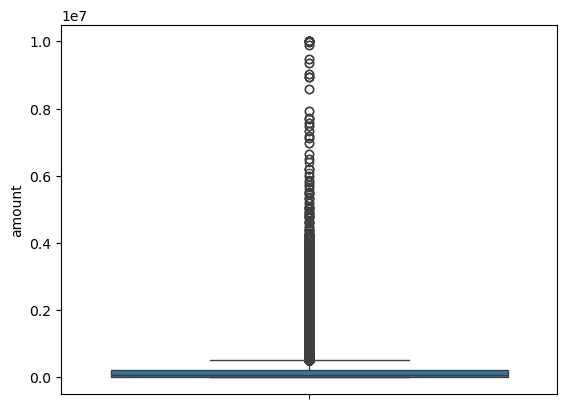

<Figure size 300x200 with 0 Axes>

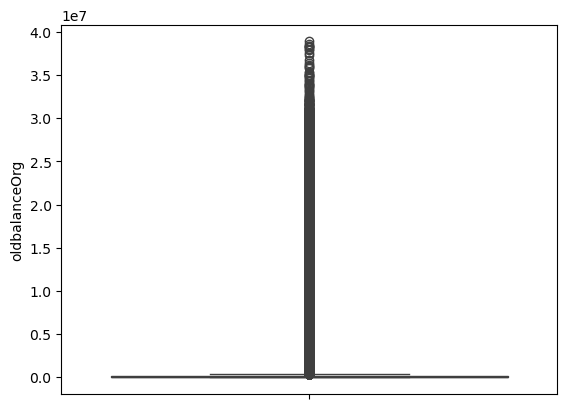

<Figure size 300x200 with 0 Axes>

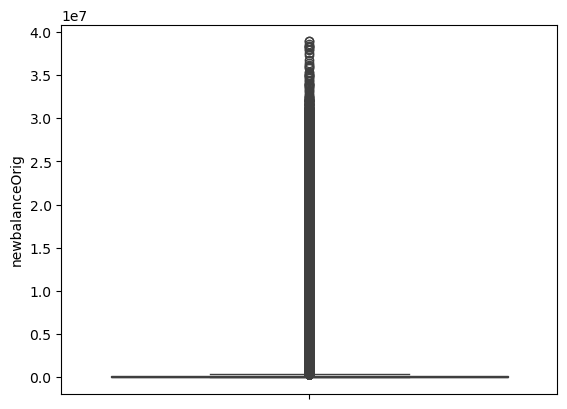

<Figure size 300x200 with 0 Axes>

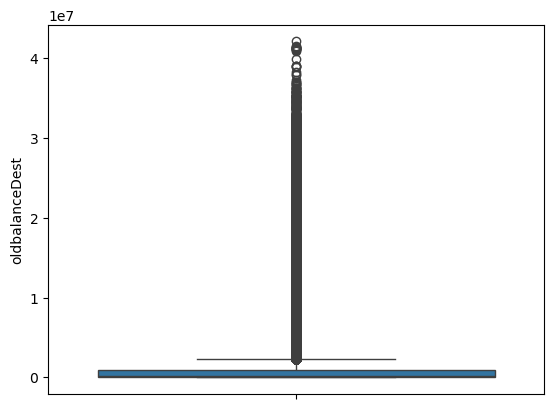

<Figure size 300x200 with 0 Axes>

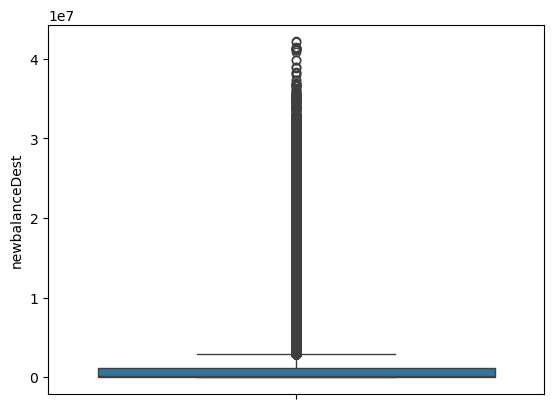

<Figure size 300x200 with 0 Axes>

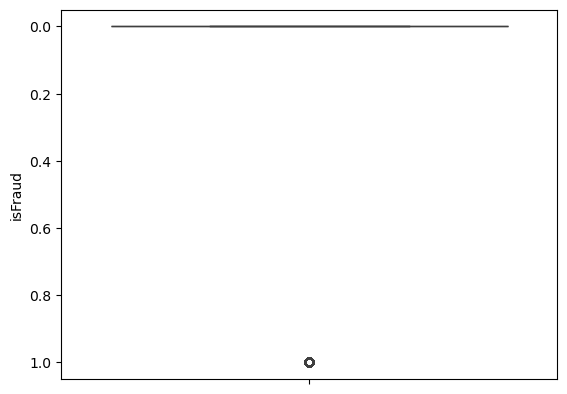

<Figure size 300x200 with 0 Axes>

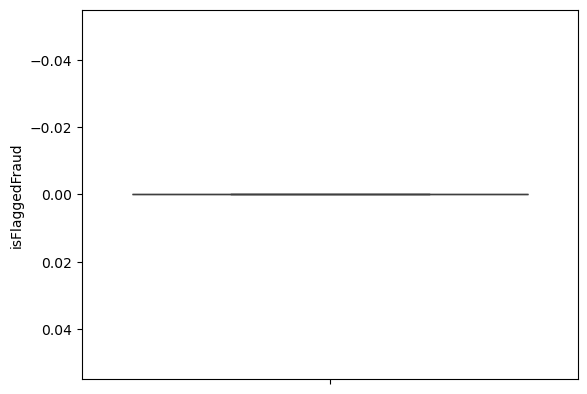

<Figure size 300x200 with 0 Axes>

In [33]:
for i in df.columns:
    if type(df[i][0])!=str:
        sns.boxplot(df[i])
        plt.figure(figsize=(3,2))
        plt.show()

**Observation:** Numerical columns show wide variation with several outliers, indicating extreme values in the data.

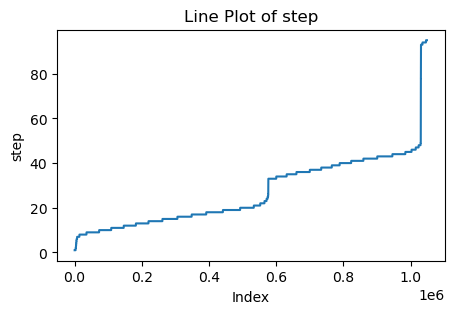

In [34]:
# Lineplot for line plot of amount
plt.figure(figsize=(5,3))
sns.lineplot(df['step'])
plt.title('Line Plot of step')
plt.xlabel('Index')
plt.ylabel('step')
plt.show()


**Observation:**
- The line plot shows a steady increasing trend in step values.
- This indicates that transactions are ordered by time.
- No sudden drops are observed, so there are no time reversals or missing time order.
- The smooth upward pattern confirms step is a time-based variable.

<Axes: title={'center': 'Transaction Types'}, ylabel='count'>

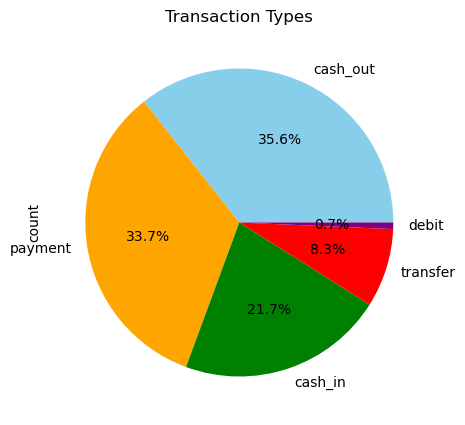

In [34]:
# Pie chart for 'type'
df['type'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), title='Transaction Types',colors=['skyblue','orange','green','red','purple'])


**Observation:**

CASH_OUT transaction type has the highest proportion in the pie chart.

***Bivariate Analysis***

In [35]:
# Categorical vs Categorical: isFlaggedFraud status vs type

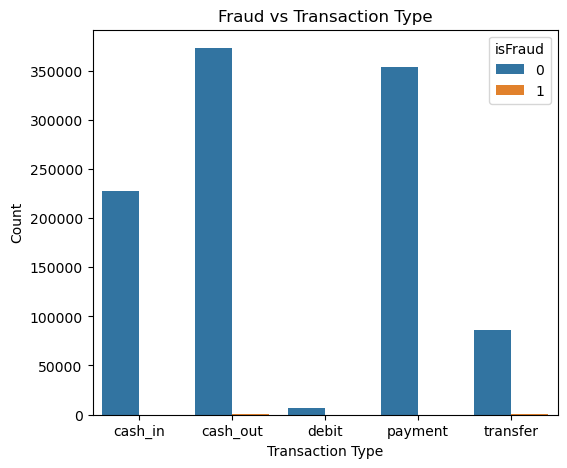

In [37]:
plt.figure(figsize=(6,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Fraud vs Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()


**Observations:**
- The countplot displays transaction types on the x-axis and separates them into fraud (1) and non-fraud (0) using different colors.
- Most transaction types are dominated by non-fraud transactions, indicating that fraudulent cases are very few in comparison.
- Fraudulent transactions are visible only in certain transaction types, showing that fraud is not evenly distributed across all types.

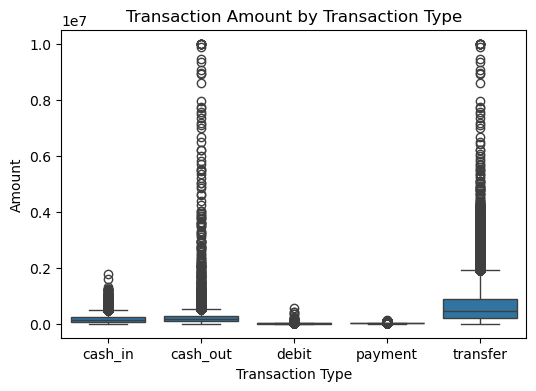

In [45]:
# Numerical vs Categorical: Transaction amount by type
plt.figure(figsize=(6,4))
sns.boxplot(x=df['type'],y=df['amount'])
plt.title('Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Amount')
plt.show()

**Observation**
- TRANSFER and CASH_OUT transactions show very high amounts with several outliers.
- DEBIT and PAYMENT transactions have relatively low amounts and fewer outliers.

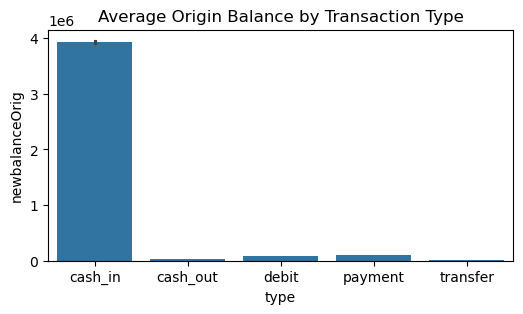

In [39]:
# Bar plot: numerical vs categorical
plt.figure(figsize=(6,3))
sns.barplot(x=df['type'],y=df['newbalanceOrig'])
plt.title('Average Origin Balance by Transaction Type')
plt.show()

**Observation:**
- Average origin balance is highest for CASH_IN and TRANSFER transactions and lowest for DEBIT and PAYMENT.

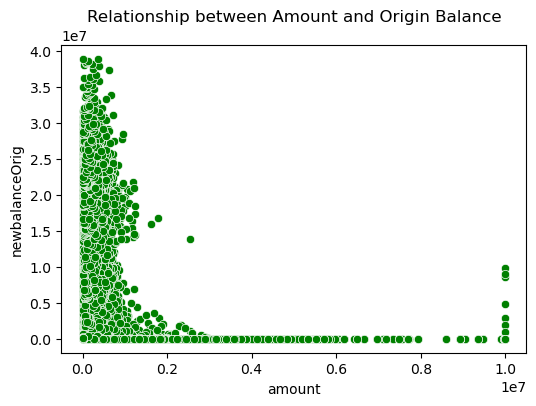

In [47]:
# Scatter plot: Numerical vs Numerical
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['amount'],y=df['newbalanceOrig'],color='green')
plt.title('Relationship between Amount and Origin Balance')
plt.xlabel("amount")
plt.ylabel("newbalanceOrig")
plt.show()


**Observation**
Most transactions have low amounts and balances, while a few large transactions stand out as outliers.

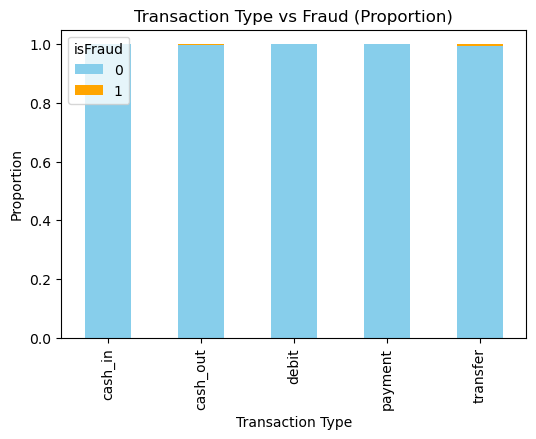

In [48]:
ct = pd.crosstab(df['type'], df['isFraud'], normalize='index')
ct.plot(kind='bar',stacked=True,figsize=(6,4),color=['skyblue', 'orange'])
plt.title("Transaction Type vs Fraud (Proportion)")
plt.xlabel("Transaction Type")
plt.ylabel("Proportion")
plt.show()


**Observation**
For all transaction types, non-fraud transactions dominate, while fraud forms only a small proportion and is mainly present in CASH_OUT and TRANSFER types.

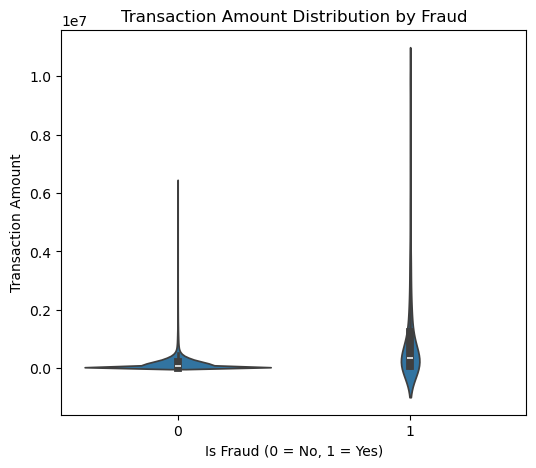

In [49]:
plt.figure(figsize=(6,5))
sns.violinplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount Distribution by Fraud')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')
plt.show()

**Observation:**
- Non-fraud transactions (0) have a wide distribution but are mostly concentrated at lower amounts.
- Fraudulent transactions (1) show higher transaction amounts with greater variability.
- This indicates that fraud is more likely to occur in high-value transactions.

***Multivariate Analysis***

In [50]:
df.dtypes

step                 int64
type              category
amount             float64
nameOrig          category
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest          category
oldbalanceDest     float64
newbalanceDest     float64
isFraud           category
isFlaggedFraud    category
dtype: object

In [51]:
# Find correlation between numerical columns
corr = df[['step', 'amount', 'newbalanceOrig', 'newbalanceDest', 'isFraud']].corr()
corr


,step,amount,newbalanceOrig,newbalanceDest,isFraud
step,1.000000,-0.025996,-0.007180,-0.019503,0.045030
amount,-0.025996,1.000000,-0.001133,0.311936,0.128862
newbalanceOrig,-0.007180,-0.001133,1.000000,0.063725,-0.009438
newbalanceDest,-0.019503,0.311936,0.063725,1.000000,-0.000495
isFraud,0.045030,0.128862,-0.009438,-0.000495,1.000000


<Axes: >

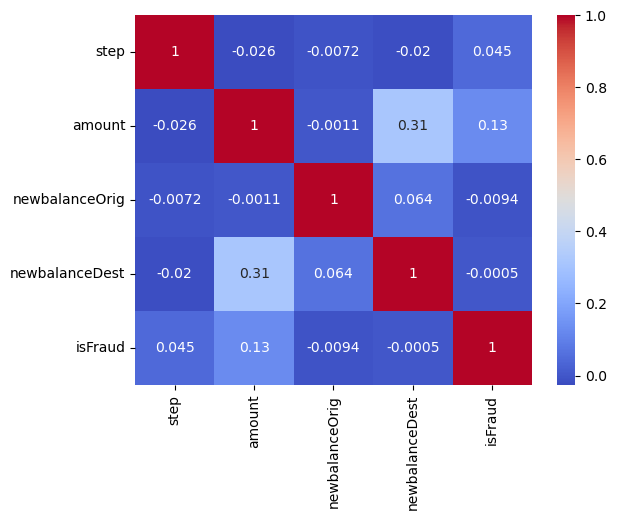

In [52]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

**Observation**
- Transaction amount shows a positive correlation with destination balance and a slight correlation with fraud, while other features have weak relationships.

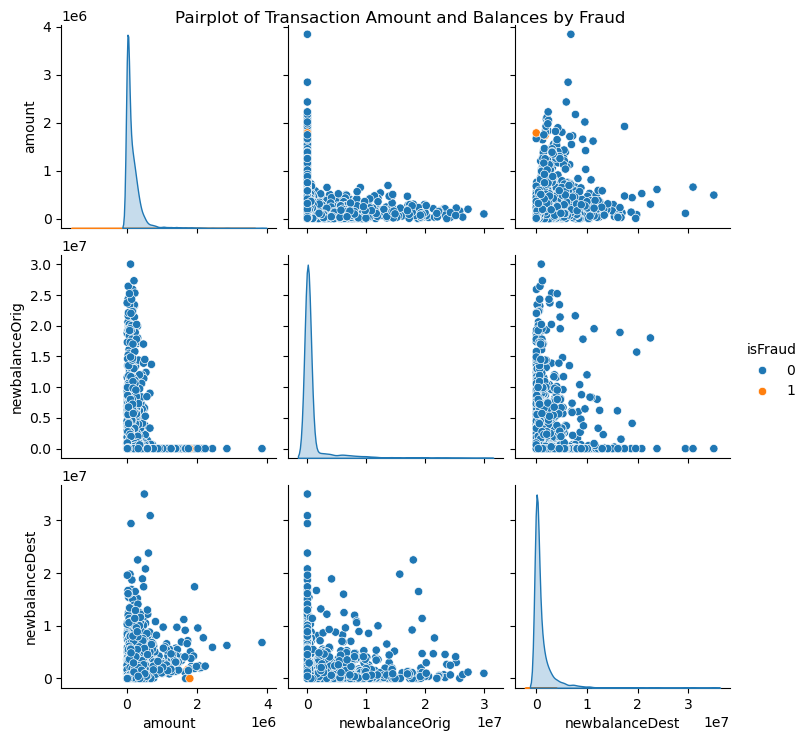

In [53]:
# Take a sample (very important for large datasets)
sample_df = df.sample(5000)
# Pairplot using numeric columns with hue
sns.pairplot(data=sample_df,vars=['amount', 'newbalanceOrig', 'newbalanceDest'],hue='isFraud')
plt.suptitle('Pairplot of Transaction Amount and Balances by Fraud')
plt.show()


**Observation:**
- Fraud cases are rare but tend to appear at higher transaction amounts and balances, while most non-fraud transactions cluster at lower values.